# Exercise: Neural Networks

## 1. Import the required libraries in the cell below

In [1]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


## 2. Read the data

In [2]:
housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768


## 3. Conduct Exploratory Data Analysis 

In [3]:
# Check data info
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   street     985 non-null    object 
 1   city       985 non-null    object 
 2   zip        985 non-null    int64  
 3   state      985 non-null    object 
 4   beds       985 non-null    int64  
 5   baths      985 non-null    int64  
 6   sq__ft     985 non-null    int64  
 7   type       985 non-null    object 
 8   sale_date  985 non-null    object 
 9   price      985 non-null    int64  
 10  latitude   985 non-null    float64
 11  longitude  985 non-null    float64
dtypes: float64(2), int64(5), object(5)
memory usage: 92.5+ KB


In [4]:
# Check for missing values
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [5]:
# Check data types
housing.dtypes

street        object
city          object
zip            int64
state         object
beds           int64
baths          int64
sq__ft         int64
type          object
sale_date     object
price          int64
latitude     float64
longitude    float64
dtype: object

In [7]:
# Look at the Summary Stats.
housing.describe()

,zip,beds,baths,sq__ft,price,latitude,longitude
count,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000
mean,95750.697462,2.911675,1.776650,1312.918782,233715.951269,38.445121,-121.193371
std,85.176072,1.307932,0.895371,856.123224,139088.818896,5.103637,5.100670
min,95603.000000,0.000000,0.000000,-984.000000,-210944.000000,-121.503471,-121.551704
25%,95660.000000,2.000000,1.000000,950.000000,145000.000000,38.482704,-121.446119
50%,95762.000000,3.000000,2.000000,1304.000000,213750.000000,38.625932,-121.375799
75%,95828.000000,4.000000,2.000000,1718.000000,300000.000000,38.695589,-121.294893
max,95864.000000,8.000000,5.000000,5822.000000,884790.000000,39.020808,38.668433


In [8]:
# Cleaning Steps (if needed)
housing = housing[(housing['sq__ft'] > 0) & (housing['price'] > 0)]

In [12]:
housing_clean = housing[(housing['sq__ft'] > 0) & (housing['price'] > 10000)].copy()
housing_clean = housing_clean.reset_index(drop=True)

In [13]:
housing_clean.describe()

,beds,baths,sq__ft,price,latitude,longitude
count,812.000000,812.00000,812.000000,812.000000,812.000000,812.000000
mean,3.247537,1.95936,1586.683498,229751.267241,38.577038,-121.378840
std,0.849490,0.66594,647.477210,119704.946884,0.126393,0.119483
min,1.000000,1.00000,484.000000,30000.000000,38.241514,-121.550527
25%,3.000000,2.00000,1144.000000,148750.000000,38.473804,-121.451463
50%,3.000000,2.00000,1418.500000,207986.500000,38.591720,-121.405456
75%,4.000000,2.00000,1851.000000,285000.000000,38.675024,-121.326073
max,8.000000,5.00000,4400.000000,884790.000000,39.008159,-120.597599


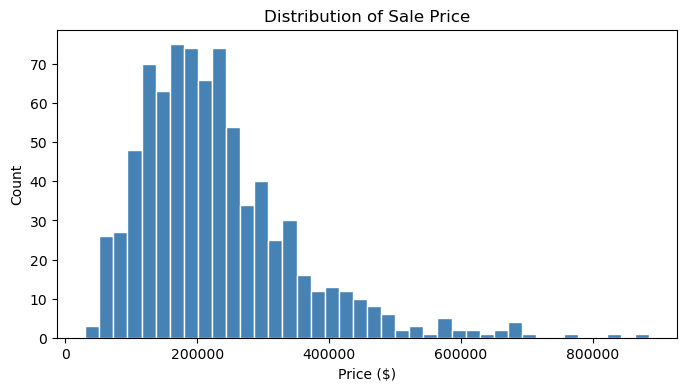

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(housing_clean['price'], bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution of Sale Price')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

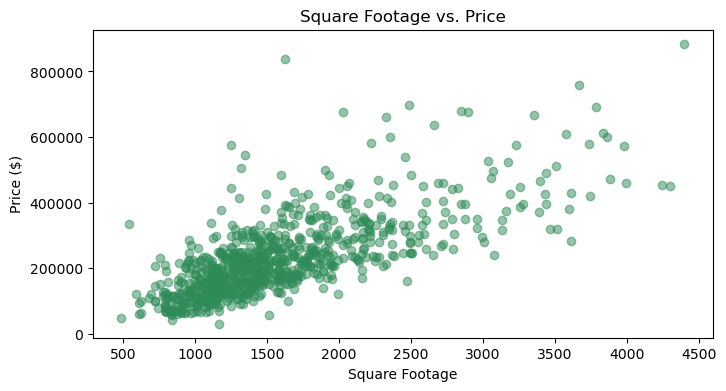

In [15]:
# Visualize the relationship between square footage and price
plt.figure(figsize=(8, 4))
plt.scatter(housing_clean['sq__ft'], housing_clean['price'], alpha=0.5, color='seagreen')
plt.title('Square Footage vs. Price')
plt.xlabel('Square Footage')
plt.ylabel('Price ($)')
plt.show()

In [16]:
# Correlation between numeric features and price
numeric_cols = ['beds', 'baths', 'sq__ft', 'price', 'latitude', 'longitude']
housing_clean[numeric_cols].corr()['price'].sort_values(ascending=False)

price        1.000000
sq__ft       0.728862
baths        0.513391
beds         0.443719
longitude    0.284564
latitude     0.057174
Name: price, dtype: float64

## 4. Split the Data & Pre-Processing
**Best Practice for Neural Network** Split your data before modeling into three part:

1. __The Training Set (The Textbook):__ This is the data the neural network actually looks at to learn. During the training loop, the network uses this data to adjust its **weights** and **biases** via backpropagation.

2. __The Validation Set (The Practice Quiz):__ This data evaluates the model *during* training to fine-tune settings. The model does not learn its weights from this data. Instead, the it uses the validation score to choose **hyperparameters** (like learning rate, number of layers, or node count) and to decide when to stop training (**early stopping**).


3. __The Test Set (The Final Exam):__ This data provides an unbiased, final evaluation of the model's real-world performance. This dataset is locked away until training is completely finished. It is only used *once* at the very end to see how well the network performs on truly unseen data.

__Typical Split Ratios__

Depending on the size of your total dataset, data scientists generally use these proportions:

| Dataset Size | Train | Validation | Test |
| :--- | :--- | :--- | :--- |
| **Traditional (Small/Medium Data)** | 60% | 20% | 20% |
| **Modern Deep Learning (Millions of Rows)** | 98% | 1% | 1% |

In [17]:
# Select the Features and Target
X = housing_clean[['sq__ft']]
y = housing_clean['price']

In [18]:
# Split to Train Test & Validation

X_train_all,X_test, y_train_all, y_test=train_test_split(X,y,test_size=.20,
                                                         random_state=42)
X_train, X_val, y_train,y_val = train_test_split(X_train_all,y_train_all,
                                                 test_size=.20,random_state=42)

In [22]:
from sklearn.preprocessing import StandardScaler
# IMPORTANT: Scale the features for Neural Networks
scaler =  StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [23]:
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled = y_scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

## 5. Linear Regression

In [24]:
# Initialize LinearRegression model
lr= LinearRegression()

In [28]:
# Fit and check the Training Score
lr.fit(X_train_scaled, y_train)
train_score = lr.score(X_train_scaled, y_train)
print(f"Training : {train_score:.4f}")

Training : 0.5105


In [29]:
# Predict and check the Testing Score
y_pred_lr = lr.predict(X_test_scaled)
test_score = lr.score(X_test_scaled, y_test)
print(f"Testing : {test_score:.4f}")

Testing : 0.5662


In [30]:
# Evaluate the model
# Coefficient 
print(f"Coefficient: {lr.coef_[0]:.2f}")

# Intercept
print(f"Intercept: {lr.intercept_:.2f}")

# RMSE
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
print(f"RMSE: {rmse_lr:.2f}")

Coefficient: 86593.78
Intercept: 234091.34
RMSE: 75488.74


## 6. Build a Single Neural Network
Creating a model in `keras` entails a few steps:
1. Create your network topology
2. Compile your model
3. Fit your model
   
**Important Note on Regression:**
Because we are predicting a continuous value (house price), our network is performing regression, not classification. 
* Your **hidden layers** should generally use the `relu` activation function.
* Your **output layer** must have exactly **1 neuron** and **no activation function** (or `activation='linear'`) so it can predict any continuous number.
* When compiling, use `loss='mse'` (Mean Squared Error) and `metrics=['mae']` (Mean Absolute Error) so we can see the error in actual dollar amounts.

In [32]:
# Step 1: Define
model=Sequential()

model.add(Input(shape=(1,))) # shape is number of features passed
model.add(Dense(1,activation=('linear')))


# Step 2: Compile 
model.compile(loss='mse') 



# Step 3: Fit
model.fit(X_train,y_train,
          validation_data=(X_val, y_val))


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 68533534720.0000 - val_loss: 62739415040.0000


In [33]:
# Model Weights
model.weights


[<Variable path=sequential/dense/kernel, shape=(1, 1), dtype=float32, value=[[0.06453265]]>,
 <Variable path=sequential/dense/bias, shape=(1,), dtype=float32, value=[0.02553287]>]

In [34]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (28.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4 (20.00 B)

## 7. Stacking Multiple Neurons

#### Shallow NN

In [35]:
# Step 1: Define
model=Sequential()

model.add(Input(shape=(1,)))  #input layer with 1 feature
model.add(Dense(3))  # hidden layer with 3 neurons (nodes
model.add(Dense(1))  # output layer



# Step 2: Compile 
model.compile(loss='mse')



# Step 3: Fit

model.fit(X_train, y_train,
          validation_data=(X_val, y_val))

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 72571404288.0000 - val_loss: 62688817152.0000


In [37]:
# Model Weights
model.weights

[<Variable path=sequential_1/dense_1/kernel, shape=(1, 3), dtype=float32, value=[[-0.21013446  0.7459535   0.7905156 ]]>,
 <Variable path=sequential_1/dense_1/bias, shape=(3,), dtype=float32, value=[-0.02532837 -0.02458312  0.02526721]>,
 <Variable path=sequential_1/dense_2/kernel, shape=(3, 1), dtype=float32, value=[[-0.281223  ]
  [-0.25385714]
  [ 0.32846525]]>,
 <Variable path=sequential_1/dense_2/bias, shape=(1,), dtype=float32, value=[0.02495269]>]

In [38]:
# Model Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

#### Deep Network

In [39]:
# use multiple hidden layers with different neurons

# Step 1: Define
model=Sequential()

model.add(Input(shape=(1,)))  #input layer with 1 feature
model.add(Dense(30))  # hidden layer with 3 neurons (nodes
model.add(Dense(20))
model.add(Dense(15))
model.add(Dense(1))  # output layer


# Step 2: Compile 
model.compile(loss='mse')



# Step 3: Fit
model.fit(X_train, y_train,
          validation_data=(X_val, y_val))


17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 73862807552.0000 - val_loss: 61290164224.0000


In [40]:
# Model Weights
model.weights

[<Variable path=sequential_2/dense_3/kernel, shape=(1, 30), dtype=float32, value=[[-0.10362308  0.28096178 -0.05009316  0.10785421 -0.44398263  0.18900713
   -0.10734137  0.08481394  0.06976707 -0.07741769 -0.05569443  0.09817372
   -0.0943903  -0.21848324  0.18452394  0.07567725 -0.20625444 -0.11402376
   -0.25465393  0.16051757 -0.04357398  0.02474283  0.26666632  0.42791444
   -0.20030808  0.27926204 -0.45398024  0.3604142  -0.2124949  -0.20971112]]>,
 <Variable path=sequential_2/dense_3/bias, shape=(30,), dtype=float32, value=[-0.0279936   0.02122205 -0.03088937 -0.02490146 -0.02785411  0.0277706
   0.02238153  0.03353448 -0.01813919 -0.03106403 -0.03307636 -0.02565609
  -0.03020013 -0.02969751  0.02776384 -0.02168861 -0.02669294  0.02202868
  -0.0266062  -0.02241293 -0.02659427 -0.02300233  0.02836677  0.00898544
   0.00363319  0.02920822 -0.02896927  0.03224088 -0.02626839  0.00785203]>,
 <Variable path=sequential_2/dense_4/kernel, shape=(30, 20), dtype=float32, value=[[ 3.418688

In [41]:
# Model Summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 30)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │           315 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,024 (7.91 KB)

 Trainable params: 1,011 (3.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,013 (3.96 KB)

## 8. Activation Functions

In [42]:
# from keras.layers import Activation 
# Note: import Activation if you use it as a standalone layer
# Step 1: Define
model = Sequential()

model.add(Input(shape=(1,)))   # number of features in input
model.add(Dense(3,activation='relu'))  # hidden layer and activation 
model.add(Dense(1,activation='linear'))   # output layer with linear activation


# Step 2: Compile 
model.compile(loss='mse')



# Step 3: Fit
model.fit(X_train,y_train, validation_data=(X_val,y_val))



17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 69492809728.0000 - val_loss: 62890000384.0000


In [43]:
# Model Weights
model.weights

[<Variable path=sequential_3/dense_7/kernel, shape=(1, 3), dtype=float32, value=[[-1.100604   -0.36363178  0.1827034 ]]>,
 <Variable path=sequential_3/dense_7/bias, shape=(3,), dtype=float32, value=[ 0.          0.         -0.02497322]>,
 <Variable path=sequential_3/dense_8/kernel, shape=(3, 1), dtype=float32, value=[[-0.06584585]
  [ 0.37493193]
  [-0.7026233 ]]>,
 <Variable path=sequential_3/dense_8/bias, shape=(1,), dtype=float32, value=[0.02511151]>]

In [44]:
# Model Summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

## 9. Epochs

In [45]:
# Step 1: Define
model = Sequential()

model.add(Input(shape=(1,)))   # number of features in input
model.add(Dense(3,activation='relu'))  # hidden layer and activation 
model.add(Dense(1,activation='linear'))   # output layer with linear activation



# Step 2: Compile 
model.compile(loss='mae')



# Step 3: Fit

model.fit(X_train,y_train, 
          validation_data=(X_val,y_val),
          epochs=5)

Epoch 1/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 233713.0938 - val_loss: 219893.8594
Epoch 2/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 231481.8125 - val_loss: 219852.5625
Epoch 3/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 227265.2031 - val_loss: 219812.2500
Epoch 4/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 236382.5156 - val_loss: 219770.1406
Epoch 5/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 226504.1250 - val_loss: 219728.3438


In [46]:
# Model Weights
model.weights

[<Variable path=sequential_4/dense_9/kernel, shape=(1, 3), dtype=float32, value=[[ 0.7624916 -1.069735  -0.4975459]]>,
 <Variable path=sequential_4/dense_9/bias, shape=(3,), dtype=float32, value=[0.09499626 0.         0.        ]>,
 <Variable path=sequential_4/dense_10/kernel, shape=(3, 1), dtype=float32, value=[[0.86388814]
  [0.13642275]
  [0.38628066]]>,
 <Variable path=sequential_4/dense_10/bias, shape=(1,), dtype=float32, value=[0.09414113]>]

In [48]:
# Model Summary
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

## 10. Batch size (Chunks)

In [49]:
# Use the validation
# Step 1: Define
model = Sequential()

model.add(Input(shape=(1,)))   # number of features in input
model.add(Dense(3,activation='relu'))  # hidden layer and activation 
model.add(Dense(1,activation='linear'))   # output layer with linear activation



# Step 2: Compile 
model.compile(loss='mae')


# Step 3: Fit
model.fit(X_train,y_train, 
          validation_data=(X_val,y_val),
          epochs=50,
          batch_size=64)


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 236070.3594 - val_loss: 220107.8750
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 235233.0625 - val_loss: 220074.6875
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 232530.7031 - val_loss: 220042.5312
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 235305.4219 - val_loss: 220010.6562
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 235656.2812 - val_loss: 219979.7969
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 235952.3281 - val_loss: 219948.6094
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 227579.8438 - val_loss: 219915.5000
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 233819.5156 - val_loss: 219882.2812
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 233925.2969 - val_loss: 219847.6406
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 230082.2188 - val_loss: 219814.5000
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 229455.5625

In [50]:
# Model Weights
model.weights

[<Variable path=sequential_5/dense_11/kernel, shape=(1, 3), dtype=float32, value=[[ 1.2962252  1.2305334 -0.7267237]]>,
 <Variable path=sequential_5/dense_11/bias, shape=(3,), dtype=float32, value=[0.46651867 0.47213203 0.        ]>,
 <Variable path=sequential_5/dense_12/kernel, shape=(3, 1), dtype=float32, value=[[0.7999758 ]
  [0.58788264]
  [0.21361518]]>,
 <Variable path=sequential_5/dense_12/bias, shape=(1,), dtype=float32, value=[0.45913923]>]

In [51]:
# Model Summary
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

Try a different batch size. 

__Note:__ the best practice to have the value in powers of 2

In [52]:
# Use the validation
# Step 1: Define
model = Sequential()

model.add(Input(shape=(1,)))   # number of features in input
model.add(Dense(3,activation='relu'))  # hidden layer and activation 
model.add(Dense(1,activation='linear'))   # output layer with linear activation


# Step 2: Compile 
model.compile(loss='mae')



# Step 3: Fit
model.fit(X_train,y_train, 
          validation_data=(X_val,y_val),
          epochs=50,
          batch_size=10)


Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 232502.2656 - val_loss: 220592.1094
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 232868.0469 - val_loss: 220535.9844
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 226609.3594 - val_loss: 220471.3906
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 229871.9219 - val_loss: 220398.4219
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 232092.0938 - val_loss: 220317.9375
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 229918.1562 - val_loss: 220227.7188
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 235667.5469 - val_loss: 220131.1094
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 236794.1875 - val_loss: 220025.7031
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 238599.5938 - val_loss: 219911.4219
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 232271.2031 - val_loss: 219788.4844
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 

In [ ]:
# Model Weights
model.weights

In [53]:
# Model Summary
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

## 11. History

**The Three Main Reasons to Use History**
  1. To Spot Overfitting
  2. To Visualise the Learning Curve
  3. To Know When to Stop Training

By saving the output of `model.fit()` to a variable (usually called `history`), Keras keeps a record of the training loss and validation loss at the end of each epoch. 

Plotting these two lines together helps us diagnose our model:
* If training loss goes down but validation loss goes up, the model is **overfitting** (memorizing the training data).
* If both are going down, the model is still learning.
* If both have flattened out, the model has converged and stopped learning.

In [54]:
# Use the validation
# Step 1: Define
model = Sequential()

model.add(Input(shape=(1,)))   # number of features in input
model.add(Dense(3,activation='relu'))  # hidden layer and activation 
model.add(Dense(1,activation='linear'))   # output layer with linear activation


# Step 2: Compile 
model.compile(loss='mae')


# Step 3: Fit
history = model.fit(X_train,y_train, 
          validation_data=(X_val,y_val),
          epochs=50,
          batch_size=64)



Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 228966.6719 - val_loss: 220953.5625
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 230671.1094 - val_loss: 220939.9531
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 233226.9688 - val_loss: 220927.5312
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 234476.0469 - val_loss: 220915.1562
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 230840.6406 - val_loss: 220904.3906
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 232768.3906 - val_loss: 220893.3281
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 234118.0781 - val_loss: 220882.7344
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 235720.4219 - val_loss: 220872.2344
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 242674.2188 - val_loss: 220862.1562
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 233673.6094 - val_loss: 220851.8438
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 233112.0469

In [55]:
# Model Weights
model.weights

[<Variable path=sequential_7/dense_15/kernel, shape=(1, 3), dtype=float32, value=[[-0.14011824 -0.32626897  0.762692  ]]>,
 <Variable path=sequential_7/dense_15/bias, shape=(3,), dtype=float32, value=[0.        0.        0.0542375]>,
 <Variable path=sequential_7/dense_16/kernel, shape=(3, 1), dtype=float32, value=[[0.32494414]
  [1.150236  ]
  [0.23460105]]>,
 <Variable path=sequential_7/dense_16/bias, shape=(1,), dtype=float32, value=[0.45913923]>]

In [56]:
# Model Summary
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

In [57]:
# Create a History Data Frame
history_df = pd.DataFrame(history.history)
history_df

,loss,val_loss
0,234336.000000,220953.562500
1,234317.890625,220939.953125
2,234304.156250,220927.531250
3,234291.281250,220915.156250
4,234278.671875,220904.390625
5,234267.265625,220893.328125
6,234255.718750,220882.734375
7,234244.531250,220872.234375
8,234233.578125,220862.156250
9,234222.937500,220851.843750


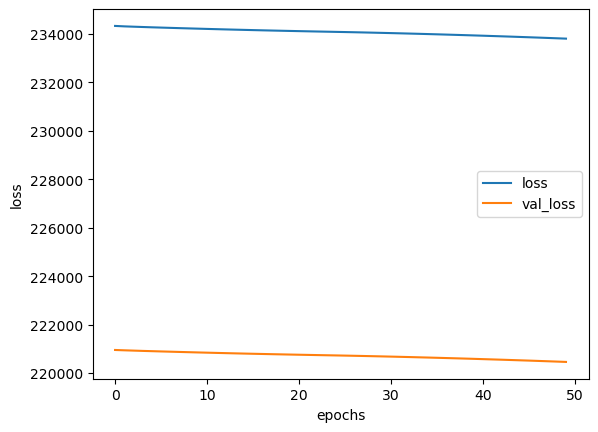

In [58]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
history_df.plot()
plt.xlabel('epochs')
plt.ylabel('loss');

## 12. Early Stopping (callback)

- Prevent overfitting
- will not waste the computing power
- save time
  
It is hard to guess exactly how many epochs a model needs. If you train for too few epochs, the model underfits. If you train for too many, it overfits. 

An **Early Stopping Callback** acts as an automatic brake. It monitors the validation loss and automatically stops training once the validation score stops improving, even if you haven't reached your maximum number of epochs. It can also automatically restore the model's best weights!

In [59]:
# configure EarlyStopping parameters
es=EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True)


In [63]:
# configure EarlyStopping parameters
early_stop = EarlyStopping(
    monitor='val_loss',      # watch the validation loss
    patience=10,              # stop after 10 epochs with no improvement
    restore_best_weights=True # roll back to the best-performing weights
)

In [65]:
# Use the validation
# Step 1: Define
model_es = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1)
])

# Step 2: Compile 
model_es.compile(optimizer='adam', loss='mse', metrics=['mae'])



# Step 3: Fit
history_es = model_es.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=200,               # set a high max -- EarlyStopping will cut training short
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)
print(f"Training stopped after {len(history_es.history['loss'])} epochs")

Training stopped after 29 epochs


In [66]:
# Model Weights
model_es.weights

[<Variable path=sequential_11/dense_26/kernel, shape=(1, 16), dtype=float32, value=[[-0.32818896 -0.45167392  0.29715964  0.6590075   0.51378816 -0.05813922
   -0.14382957 -0.10140517 -0.45236188 -0.18880327  0.19737683  0.4502663
   -0.24803382 -0.21941866 -0.09357437 -0.10917681]]>,
 <Variable path=sequential_11/dense_26/bias, shape=(16,), dtype=float32, value=[ 0.00011382  0.00861782  0.08270384  0.06573717  0.07349999  0.06719454
   0.09819227  0.04952144 -0.00183495  0.03571051 -0.06680746 -0.07309386
   0.01457179  0.01142692 -0.03321124  0.07205901]>,
 <Variable path=sequential_11/dense_27/kernel, shape=(16, 8), dtype=float32, value=[[ 0.09465568  0.4950954  -0.13472599  0.13078213 -0.38347912  0.22160524
    0.33174443 -0.40381694]
  [-0.04463573  0.42097285 -0.29732668  0.24485633 -0.25139183  0.47562835
   -0.29007828 -0.533277  ]
  [-0.21662575  0.22173735 -0.30775604  0.17336287  0.4340902  -0.3708631
   -0.20891738 -0.08718629]
  [ 0.13504426 -0.24583378  0.19338645  0.293

In [67]:
# Model Summary
model_es.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533 (2.09 KB)

 Trainable params: 177 (708.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 356 (1.39 KB)

In [68]:
# Create a History Data Frame
history_es_df = pd.DataFrame(history_es.history)
history_es_df.head()

,loss,mae,val_loss,val_mae
0,1.017557,0.693100,0.803837,0.624292
1,0.864123,0.631899,0.680967,0.568856
2,0.756385,0.590968,0.594363,0.532918
3,0.670299,0.558256,0.532881,0.505159
4,0.607242,0.539446,0.491678,0.491462


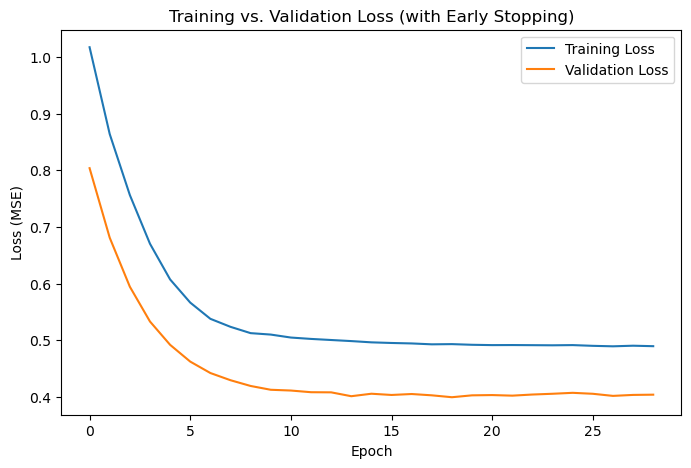

In [69]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history_es_df['loss'], label='Training Loss')
plt.plot(history_es_df['val_loss'], label='Validation Loss')
plt.title('Training vs. Validation Loss (with Early Stopping)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

## 13.Multi-Feature Neural Network

In [70]:
# configure EarlyStopping parameters
early_stop_mf = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


In [73]:
housing_clean.dropna(inplace=True)

In [87]:
housing_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 812 entries, 0 to 811
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   street     812 non-null    object             
 1   city       812 non-null    object             
 2   zip        812 non-null    object             
 3   state      812 non-null    object             
 4   beds       812 non-null    int64              
 5   baths      812 non-null    int64              
 6   sq__ft     812 non-null    int64              
 7   type       812 non-null    object             
 8   sale_date  812 non-null    datetime64[ns, UTC]
 9   price      812 non-null    int64              
 10  latitude   812 non-null    float64            
 11  longitude  812 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(2), int64(4), object(5)
memory usage: 76.3+ KB


In [88]:
# تحديد الأعمدة الرقمية كمدخلات للنموذج
numeric_features = ['beds', 'baths', 'sq__ft', 'latitude', 'longitude']
X = housing_clean[numeric_features].astype('float64')

# تحديد السعر كهدف للتوقع
y = housing_clean['price'].astype('float64')

In [89]:
X_train_all, X_test,y_train_all, y_test=train_test_split(X,y,test_size=0.2,
                                                         random_state=42)

X_train,X_val,y_train,y_val = train_test_split(X_train_all, y_train_all,
                                               test_size=0.2,random_state=42)


In [91]:
# Use the validation
# Step 1: Define
model = Sequential([
    Input(shape=(5,)),
    Dense(20,activation='relu'),
    Dense(15,activation='relu'),
    Dense(1, activation='linear')
          ])


# Step 2: Compile 

model.compile(loss='mae')  # the loss function used for training


# Step 3: Fit
history = model.fit(X_train,y_train,
                    validation_data=(X_val,y_val),
                    epochs=50,
                    batch_size=64,
                    callbacks=[es])



Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 238064.9375 - val_loss: 220211.6719
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 236558.0625 - val_loss: 220085.9062
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 235201.8281 - val_loss: 219958.8281
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 228749.2344 - val_loss: 219829.6562
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 237470.4062 - val_loss: 219697.0938
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 235311.0156 - val_loss: 219553.0781
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 229975.8438 - val_loss: 219397.3438
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 234405.4062 - val_loss: 219231.6094
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 230851.0156 - val_loss: 219062.1250
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 233633.9219 - val_loss: 218883.4219
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 229595.5469

In [92]:
# Model Weights
model.weights


[<Variable path=sequential_17/dense_44/kernel, shape=(5, 20), dtype=float32, value=[[ 0.24732424 -0.1276741   0.3522155   0.30374393 -0.11920592  0.27084228
    0.41254306  0.6403396   0.92741907 -0.21051913  0.28217787  0.08085641
    0.49970064  0.96969056  0.29637328  0.94521976 -0.20079523 -0.23991367
    0.2814605   0.40136924]
  [ 0.45462477  0.08765569 -0.2213065   0.26241782 -0.4672943  -0.0521144
    0.34784773  0.11642572  0.6438331  -0.40832078 -0.00387272  0.48430154
    0.29885292  0.48605207  0.6207987   0.27073923  0.06989524  0.21951593
    0.21384254  0.2871478 ]
  [ 0.5970601  -0.08560306 -0.43068755 -0.291924   -0.0173538  -0.39252663
    0.931353    0.5156557   0.92692995 -0.43711707  0.47327706 -0.08043694
    0.88199884  0.60924786  0.5124483   0.44245768 -0.26334637  0.00597406
    0.7700463  -0.39918205]
  [ 0.5264792  -0.28006348  0.40304348 -0.10882583 -0.25625739 -0.05787945
    0.02716091  0.37386137  0.05211123  0.38227376  0.8522787  -0.4586195
    0.44786

In [94]:
# Model Summary
model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 20)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 15)             │           315 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 904 (3.54 KB)

 Trainable params: 451 (1.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 453 (1.77 KB)

In [95]:
# Create a History Data Frame
history_df= pd.DataFrame(history.history)
history_df

,loss,val_loss
0,233636.859375,220211.671875
1,233489.421875,220085.906250
2,233357.734375,219958.828125
3,233222.921875,219829.656250
4,233085.578125,219697.093750
5,232940.859375,219553.078125
6,232783.515625,219397.343750
7,232617.062500,219231.609375
8,232440.609375,219062.125000
9,232257.000000,218883.421875


Text(0, 0.5, 'loss')

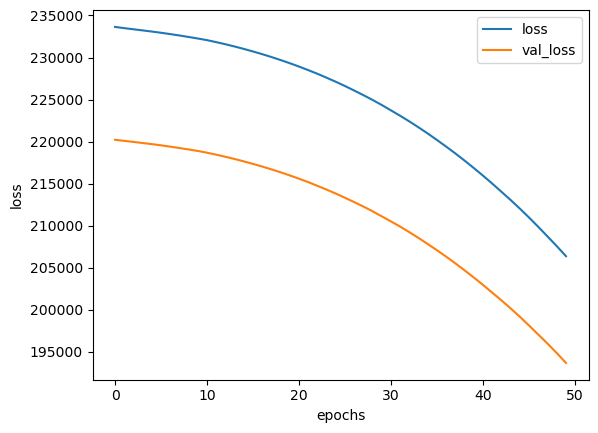

In [96]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
history_df.plot()
plt.xlabel("epochs")
plt.ylabel("loss")